In [41]:
from pydantic import BaseModel
from langchain_core.messages import BaseMessage
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
import os
from datetime import datetime
from IPython.display import Image, display

In [32]:
# llm credentials
api_key = os.getenv("OPENROUTER_API_KEY")
base_url = 'https://openrouter.ai/api/v1'

In [110]:
# helper function for llm

def get_llm(model):    
    return ChatOpenAI(model=model, api_key=api_key, base_url=base_url)

def get_system_prompt(role, goal, backstory):
    system_prompt =f"""
    You are a ${backstory} \n\n
    Role: {role}\n\n
    Goal: {goal}
    """
    return system_prompt

def get_user_prompt(task, expected_output, **contexts):
    system_prompt = ""
    if contexts:
        for source, context in contexts.items():
            system_prompt += f"Context from {source}: {context}\n\n"
    
    system_prompt +=f"""
    Task: {task} \n\n
    Expected output: {expected_output}
    """
    return system_prompt


def merge_role_messages(old, new):
    old = old or {}
    new = new or {}

    merged = {**old}

    for role, msgs in new.items():
        existing = merged.get(role, [])
        merged[role] = add_messages(existing, msgs)

    return merged

# save output in md file
def output_to_markdown(content, filename, folder = "output"):
    os.makedirs(folder, exist_ok=True)
    filepath = os.path.join(folder, filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(content)
    return filepath

In [109]:
# state to tack all messages

class State(BaseModel):
    current_year: str = str(datetime.now().year)
    messages: Annotated[dict[str, list[BaseMessage]], merge_role_messages]
    idea: str
    industry: str


In [95]:
# let's build the graph
graph_builder = StateGraph(State)

# Agents
# - researcher
def researcher(old_state: State):
    current_year = old_state.current_year
    idea = old_state.idea
    industry = old_state.industry


    #system prompt
    role = f"Identify the market landscape, target users, and existing competitors for a startup idea. The idea: {idea}"
    goal = f"Market intelligence specialist focused on extracting factual, external context about a startup idea. The idea: {idea}"
    backstory = f"""
     Former startup research analyst who has evaluated hundreds of early-stage products across industry the idea is in. The industry: {industry}. 
    Skilled at quickly identifying patterns in market demand, user segments, and competitive positioning.
    """
    #user prompt
    task = f"""
        Analyze the startup idea and identify the target users, the problem it solves, the market need, and the existing competitors. 
        Focus on factual market context and concise insight.
        The idea: {idea}.
        The current year is {current_year}.
    """
    expected_output = f"""
        A structured. professional market research summary on {idea} startup idea containing:
        1. Startup idea summary
        2. target audience
        3. problem being solved
        4. market need
        5. 3 to 5 likely competitors or alternatives
        6. brief note on current opportunity in the market
        7. conclusion
    """

    # call llm and pass the research prompt in
    system_prompt = get_system_prompt(role, goal, backstory)
    user_prompt = get_user_prompt(task,expected_output)
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    llm = get_llm("gpt-4o-mini")
    response = llm.invoke(messages)
    data = old_state.model_dump()
    data['messages'] = {"researcher":[response]}
    new_state =  State(**data)
    return new_state

# - critic
def critic(old_state: State):

    # value from state
    idea = old_state.idea
    researcher_output = old_state.messages['researcher'][0].content

    print(researcher_output, "researcher output")
    #system prompt
    role = f"Expose weaknesses, risks, and blind spots in a start up idea. The idea: {idea}"
    goal = f"Skeptical evaluator focused on failure modes, edge cases, and market reality checks."
    backstory = f"""
     Ex-VC associate known for rejecting weak startups. Has seen many ideas fail due to poor differentiation, execution risk, or lack of real demand.
    Optimized for critical thinking over optimism.
    """
    #user prompt
    task = f"""
        Review the {idea} startup idea using the market research output. 
    Identify weaknesses, risks, hidden assumptions, execution challenges, and reasons the idea may fail in the market.
    """
    expected_output = f"""
        A concise critical analysis containing:
        1. main risks
        2. weak assumptions
        3. differentiation concerns
        4. adoption or execution challenges
        5. overall realism assessment
    """

    # call llm and pass the critic prompt
    system_prompt = get_system_prompt(role, goal, backstory)
    user_prompt = get_user_prompt(task, expected_output, researcher_output = researcher_output)
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    llm = get_llm("gpt-4o-mini")
    response = llm.invoke(messages)
    # return output
    data = old_state.model_dump()
    data['messages'] = {"critic":[response]}
    new_state =  State(**data)
    return new_state

# - product_strategist
def product_strategist(old_state: State):

    # value from state
    idea = old_state.idea
    researcher_output = old_state.messages['researcher'][0].content
    critic_output = old_state.messages['critic'][0].content

    #system prompt
    role = f"Transform the idea into a viable, differentiated product with a clear MVP. The idea: {idea}"
    goal = f"Builder mindset focused on execution, positioning, and practical product design."
    backstory = f"""
     Product leader who has taken multiple startups from concept to launch. 
    Strong at simplifying ideas into focused MVPs and identifying the fastest path to product-market fit.
    """
    #user prompt
    task = f"""
        Using the research and critique, refine the startup idea into a sharper and more viable product concept.
    Define a focused MVP, a clearer positioning angle, and practical recommendations for improving the {idea} idea.
    """
    expected_output = f"""
        A final validation report containing:
        1. summary of the idea
        2. market opportunity snapshot
        3. key risks
        4. product strategy recommendation
        5. final verdict: Proceed, Refine, or Reject
        6. short rationale for the verdict
    """

    # call llm and pass the critic prompt
    system_prompt = get_system_prompt(role, goal, backstory)
    user_prompt = get_user_prompt(task, expected_output, researcher_output=researcher_output, critic_output=critic_output)
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    llm = get_llm("gpt-4o-mini")
    response = llm.invoke(messages)
    # return output
    data = old_state.model_dump()
    data['messages'] = {"product":[response]}
    new_state =  State(**data)
    return new_state

# - evalsynthesizer
def synthesizer(old_state: State):
    
     # value from state
    idea = old_state.idea
    researcher_output = old_state.messages['researcher'][0].content
    critic_output = old_state.messages['critic'][0].content
    product_output = old_state.messages['product'][0].content

    #system prompt
    role = f"Produce a clear, structured, decision-ready evaluation of the idea. The idea: {idea}"
    goal = f"Decision intelligence layer that combines all prior outputs into a coherent recommendation."
    backstory = f"""
     Strategy consultant experienced in turning fragmented insights into executive-level reports. 
    Known for clarity, structure, and actionable recommendations.
    """
    #user prompt
    task = f"""
        Present a balanced evaluation of the {idea} startup idea and provide a clear recommendation on whether to proceed, refine, or abandon the idea.
    """
    expected_output = f"""
        A final validation report containing:
        1. summary of the idea
        2. market opportunity snapshot
        3. key risks
        4. product strategy recommendation
        5. final verdict: Proceed, Refine, or Reject
        6. short rationale for the verdict
    """

    # call llm and pass the critic prompt
    system_prompt = get_system_prompt(role, goal, backstory)
    user_prompt = get_user_prompt(task, expected_output, researcher_output=researcher_output, critic_output=critic_output, product_strategist_output=product_output)
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    llm = get_llm("gpt-4o-mini")
    response = llm.invoke(messages)
    # return output
    data = old_state.model_dump()
    data['messages'] = {"judge":[response]}
    new_state =  State(**data)
    return new_state

In [96]:
# node registration
graph_builder.add_node('researcher', researcher)
graph_builder.add_node('critic', critic)
graph_builder.add_node('product_strategist', product_strategist)
graph_builder.add_node('judge', synthesizer)

In [97]:
# setup edges
# Step 4: Create Edges
graph_builder.add_edge(START, "researcher")
graph_builder.add_edge("researcher", "critic")
graph_builder.add_edge("critic", "product_strategist")
graph_builder.add_edge("product_strategist", "judge")
graph_builder.add_edge("judge", END)

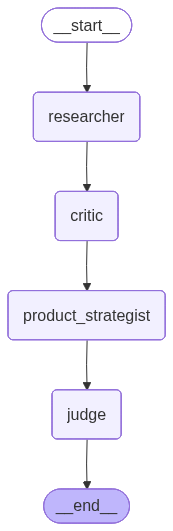

In [82]:
#compile graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [111]:
#main running
def run_graph(idea, industry):
     graph = graph_builder.compile()
     initial_state = State(messages={}, idea= idea, industry=industry)
     result = graph.invoke(initial_state)
     if result:
          for key, content in result['messages'].items():
               output_to_markdown(content[0].content,f"{key}.md")
          print("output done")

In [99]:
result = run_graph('Ai tutor', 'Edtech')

### Market Research Summary: AI Tutor Startup Idea

#### 1. Startup Idea Summary
The AI Tutor startup aims to leverage artificial intelligence technology to provide personalized learning experiences for students. This platform will use adaptive learning algorithms to tailor educational content, pacing, and instruction to the unique needs of individual learners—from K-12 to higher education and adult learners. The AI Tutor will also incorporate real-time feedback and assessments, facilitating continuous improvement and mastery of subjects.

#### 2. Target Audience
- **K-12 Students:** Primary users in need of homework assistance and supplementary education resources.
- **Parents:** Looking for enhanced educational support for their children.
- **Higher Education Students:** University and college students seeking personalized tutoring in specific subjects.
- **Adult Learners:** Professionals and lifelong learners who want to develop new skills or knowledge in a flexible format.
- **Educ

In [104]:
print(result['messages']['judge'][0].content)

# AI Tutor Startup Validation Report

## 1. Summary of the Idea
The AI Tutor concept is designed to deliver personalized learning experiences utilizing artificial intelligence. This platform aims to adapt educational content, pacing, and instructional methods tailored to individual learning needs across a spectrum of demographics, including K-12, higher education, and adult learners. Key features will include real-time feedback, continuous assessments, and a blend of AI-driven adjustment with the option for human interaction, ensuring an enriched learning experience.

## 2. Market Opportunity Snapshot
The Edtech market is booming, projected to surpass $350 billion by 2025, fueled by the demand for personalized education solutions accelerated by the post-pandemic shift towards digital learning. There is a significant opportunity to cater to specific market segments such as:

- **K-12 students:** Engaging homework aid and a comprehensive, personalized learning pathway.
- **Higher educati